# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sufyan Billel

**Date:** 9/9/2026

In [2]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/DS3001/ForeignGifts_edu.csv')

In [5]:
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [6]:
df['FG Amount Arcsinh'] = np.arcsinh(df['Foreign Gift Amount'])

Text(0.5, 0, '')

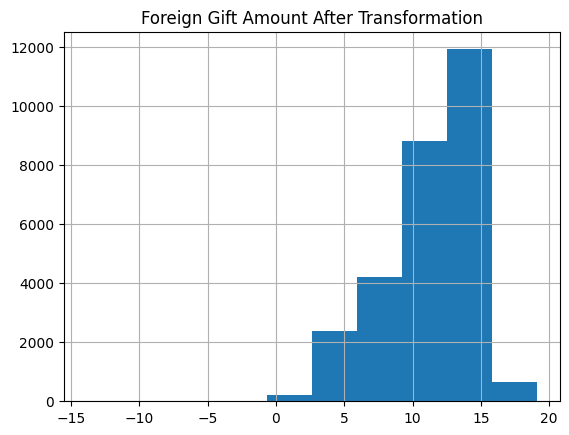

In [7]:
df['FG Amount Arcsinh'].hist()
plt.title('Foreign Gift Amount After Transformation')
plt.xlabel('')

The variable describes the am
It's skewed to the right and most observations are beteween 8,000 dollars and 11,000 dollars. There are no outliers.

In [8]:
df['Gift Type'].describe()

,Gift Type
count,28221
unique,3
top,Contract
freq,17274


In [9]:
df['Gift Type'].value_counts()

,count
Gift Type,
Contract,17274
Monetary Gift,10936
Real Estate,11


Contract: 0.61
Monetary Gift: 0.38
Real Estate: 0.00038

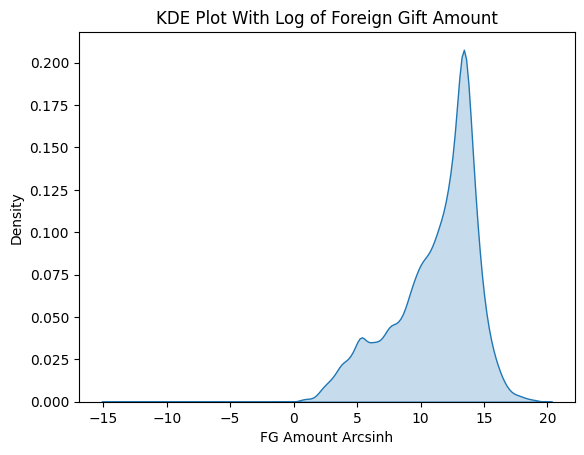

In [10]:
sns.kdeplot(data=df, x="FG Amount Arcsinh", fill=True)

plt.title("KDE Plot With Log of Foreign Gift Amount")
plt.show()

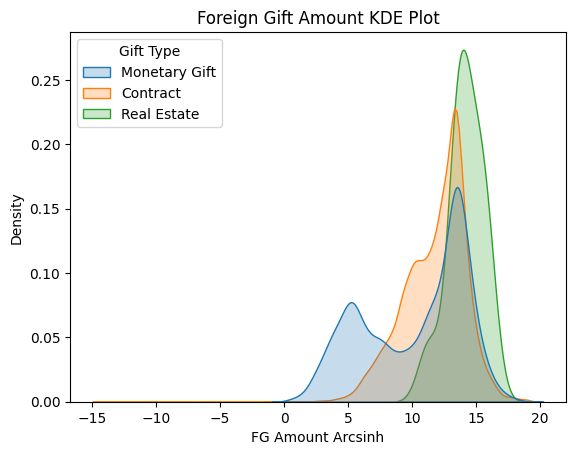

In [11]:
sns.kdeplot(data=df, x="FG Amount Arcsinh", hue="Gift Type", fill=True, common_norm=False)

plt.title("Foreign Gift Amount KDE Plot")
plt.show()

The first KDE plot shows the general shape of the data, but the KDE plot conditional on gift type shows a clearer story of where the numbers actually are. While the first KDE plot has only two peaks, the second one has a peak at 14 for monetary gifts that is buried in the first plot. So, different gift types look different but the first plot doesn't show that.

In [12]:
top_15_countries = df['Country of Giftor'].value_counts().iloc[:15].index

In [13]:
top_15_countries.unique()

Index(['ENGLAND', 'CHINA', 'CANADA', 'JAPAN', 'SWITZERLAND', 'SAUDI ARABIA',
       'FRANCE', 'GERMANY', 'HONG KONG', 'SOUTH KOREA', 'QATAR',
       'THE NETHERLANDS', 'KOREA', 'INDIA', 'TAIWAN'],
      dtype='object', name='Country of Giftor')

In [20]:
df['category_rank'] = df.groupby('Country of Giftor')['Foreign Gift Amount'].transform('sum').rank(method = 'dense', ascending=False)

In [21]:
df_sorted = df.sort_values(by='category_rank')

In [26]:
top_15_df = df[df['category_rank'] <= 15].sort_values(by='category_rank')

In [29]:
top_15_df['Country of Giftor'].unique()

array(['QATAR', 'ENGLAND', 'CHINA', 'SAUDI ARABIA', 'BERMUDA', 'CANADA',
       'HONG KONG', 'JAPAN', 'SWITZERLAND', 'INDIA', 'GERMANY',
       'UNITED ARAB EMIRATES', 'FRANCE', 'SINGAPORE', 'AUSTRALIA'],
      dtype=object)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]